<a href="https://colab.research.google.com/github/dibujoudea-boop/analizador_localizacion_login/blob/main/notebooks/analizador_localizacion_login_v4_tfm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analizador Localización de Login v4 - Notebook de validación TFM

Este notebook ejecuta la validación experimental del **Analizador Localización de Login v4**.

Flujo:
1. Clonar el repositorio GitHub.
2. Instalar dependencias.
3. Cargar el dataset sintético v4.
4. Ejecutar el analizador batch.
5. Generar métricas, tablas, figuras, Excel y ZIP.

In [1]:
# 1. Clonar repositorio e instalar dependencias

import os
import shutil

REPO_URL = "https://github.com/dibujoudea-boop/analizador_localizacion_login.git"
REPO_DIR = "analizador_localizacion_login"

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone {REPO_URL}
%cd {REPO_DIR}

!pip install -q -r requirements.txt

Cloning into 'analizador_localizacion_login'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 196 (delta 39), reused 15 (delta 15), pack-reused 153 (from 1)
Receiving objects: 100% (196/196), 2.44 MiB | 15.81 MiB/s, done.
Resolving deltas: 100% (72/72), done.
/content/analizador_localizacion_login


In [2]:
# 2. Importar librerías y módulos del proyecto

import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from src.batch_analysis import load_dataset, run_batch_analysis, build_summary_tables

In [3]:
# 3. Cargar dataset sintético v4

DATASET_PATH = "data/logins_sinteticos_v4_analizador_localizacion_login.csv"

df = load_dataset(DATASET_PATH)

print("Dimensiones del dataset:", df.shape)
display(df.head(10))

Dimensiones del dataset: (1000, 24)


,user_id,timestamp,ip,known_location,declared_city,declared_region,declared_country,timezone_offset,user_agent,device_type,...,is_hosting,ip_reputation,is_new_device,country_change,distance_from_prev_km,time_since_prev_min,travel_speed_kmh,timezone_mismatch,scenario_type,expected_result
0,u001,2026-05-02 12:59:00,181.52.219.241,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,5.2,1450.0,0.2,0,habitual,bajo
1,u001,2026-05-03 10:13:00,190.68.196.157,Bogota,Manizales,Caldas,Colombia,-05:00,Safari macOS,desktop,...,0,low,0,0,318.4,2324.0,8.2,0,legit_unusual,bajo
2,u001,2026-05-03 12:08:00,181.55.120.34,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,7.4,115.0,3.9,0,habitual,bajo
3,u001,2026-05-04 17:08:00,181.56.166.175,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,6.5,1740.0,0.2,0,habitual,bajo
4,u001,2026-05-05 08:14:00,181.50.245.203,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,4.2,906.0,0.3,0,habitual,bajo
5,u001,2026-05-05 11:20:00,159.65.2.149,Bogota,Singapore,Central,Singapore,+08:00,Unknown Bot,mobile,...,0,high,1,1,11292.1,174.0,3893.8,1,suspicious,alto
6,u001,2026-05-05 18:22:00,181.49.149.117,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,5.8,422.0,0.8,0,habitual,bajo
7,u001,2026-05-06 09:12:00,167.99.111.145,Bogota,Mexico City,CDMX,Mexico,-06:00,Headless Chrome,mobile,...,1,medium,1,1,6660.3,97.0,4119.8,1,suspicious,alto
8,u001,2026-05-07 13:02:00,181.52.128.158,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,3.5,1670.0,0.1,0,habitual,bajo
9,u001,2026-05-08 14:45:00,181.56.79.142,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,0,low,0,0,3.0,1543.0,0.1,0,habitual,bajo


In [4]:
# 4. Ejecutar el analizador batch

df_results = run_batch_analysis(df)

print("Eventos procesados:", len(df_results))
display(df_results.head(10))

Eventos procesados: 1000


,user_id,timestamp,ip,known_location,declared_city,declared_region,declared_country,timezone_offset,user_agent,device_type,...,time_since_prev_min,travel_speed_kmh,timezone_mismatch,scenario_type,expected_result,risk_score,risk_level,recommended_action,risk_reasons,comparison_result
0,u001,2026-05-02 12:59:00,181.52.219.241,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,1450.0,0.2,0,habitual,bajo,0,bajo,allow,,acierto
1,u001,2026-05-03 10:13:00,190.68.196.157,Bogota,Manizales,Caldas,Colombia,-05:00,Safari macOS,desktop,...,2324.0,8.2,0,legit_unusual,bajo,20,bajo,allow,localizacion_distinta_a_la_habitual,acierto
2,u001,2026-05-03 12:08:00,181.55.120.34,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,115.0,3.9,0,habitual,bajo,0,bajo,allow,,acierto
3,u001,2026-05-04 17:08:00,181.56.166.175,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,1740.0,0.2,0,habitual,bajo,0,bajo,allow,,acierto
4,u001,2026-05-05 08:14:00,181.50.245.203,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,906.0,0.3,0,habitual,bajo,0,bajo,allow,,acierto
5,u001,2026-05-05 11:20:00,159.65.2.149,Bogota,Singapore,Central,Singapore,+08:00,Unknown Bot,mobile,...,174.0,3893.8,1,suspicious,alto,108,alto,block_or_review,localizacion_distinta_a_la_habitual; cambio_de...,acierto
6,u001,2026-05-05 18:22:00,181.49.149.117,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,422.0,0.8,0,habitual,bajo,0,bajo,allow,,acierto
7,u001,2026-05-06 09:12:00,167.99.111.145,Bogota,Mexico City,CDMX,Mexico,-06:00,Headless Chrome,mobile,...,97.0,4119.8,1,suspicious,alto,104,alto,block_or_review,localizacion_distinta_a_la_habitual; cambio_de...,acierto
8,u001,2026-05-07 13:02:00,181.52.128.158,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,1670.0,0.1,0,habitual,bajo,0,bajo,allow,,acierto
9,u001,2026-05-08 14:45:00,181.56.79.142,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Safari macOS,mobile,...,1543.0,0.1,0,habitual,bajo,0,bajo,allow,,acierto


In [5]:
# 5. Crear tablas resumen

summary_risk, summary_action, summary_comparison, summary_by_scenario = build_summary_tables(df_results)

display(summary_risk)
display(summary_action)
display(summary_comparison)
display(summary_by_scenario)

,risk_level,count
0,bajo,725
1,medio,132
2,alto,143


,recommended_action,count
0,allow,725
1,block_or_review,143
2,step_up_mfa,132


,comparison_result,count
0,acierto,934
1,subestimacion,35
2,sobrestimacion,31


risk_level,scenario_type,alto,bajo,medio
0,ambiguous,43,33,24
1,habitual,0,650,0
2,legit_unusual,0,42,108
3,suspicious,100,0,0


In [6]:
# 6. Métricas principales

total_eventos = len(df_results)
aciertos = (df_results["comparison_result"] == "acierto").sum()
subestimaciones = (df_results["comparison_result"] == "subestimacion").sum()
sobrestimaciones = (df_results["comparison_result"] == "sobrestimacion").sum()
accuracy_global = aciertos / total_eventos

tabla_metricas = pd.DataFrame({
    "Métrica": [
        "Número total de eventos",
        "Eventos clasificados en riesgo bajo",
        "Eventos clasificados en riesgo medio",
        "Eventos clasificados en riesgo alto",
        "Acciones allow",
        "Acciones step_up_mfa",
        "Acciones block_or_review",
        "Aciertos",
        "Subestimaciones",
        "Sobrestimaciones",
        "Accuracy global"
    ],
    "Valor": [
        total_eventos,
        int((df_results["risk_level"] == "bajo").sum()),
        int((df_results["risk_level"] == "medio").sum()),
        int((df_results["risk_level"] == "alto").sum()),
        int((df_results["recommended_action"] == "allow").sum()),
        int((df_results["recommended_action"] == "step_up_mfa").sum()),
        int((df_results["recommended_action"] == "block_or_review").sum()),
        int(aciertos),
        int(subestimaciones),
        int(sobrestimaciones),
        f"{accuracy_global:.2%}".replace(".", ",")
    ]
})

display(tabla_metricas)

,Métrica,Valor
0,Número total de eventos,1000
1,Eventos clasificados en riesgo bajo,725
2,Eventos clasificados en riesgo medio,132
3,Eventos clasificados en riesgo alto,143
4,Acciones allow,725
5,Acciones step_up_mfa,132
6,Acciones block_or_review,143
7,Aciertos,934
8,Subestimaciones,35
9,Sobrestimaciones,31


Resultado obtenido,bajo,medio,alto
Resultado esperado,,,
bajo,690,13,0
medio,35,119,18
alto,0,0,125


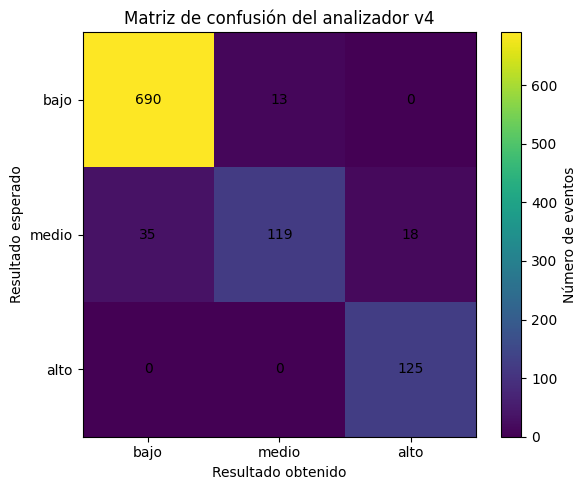

In [7]:
# 7. Matriz de confusión

matriz_confusion = pd.crosstab(
    df_results["expected_result"],
    df_results["risk_level"],
    rownames=["Resultado esperado"],
    colnames=["Resultado obtenido"]
).reindex(
    index=["bajo", "medio", "alto"],
    columns=["bajo", "medio", "alto"],
    fill_value=0
)

display(matriz_confusion)

plt.figure(figsize=(6, 5))
plt.imshow(matriz_confusion, aspect="auto")
plt.title("Matriz de confusión del analizador v4")
plt.xlabel("Resultado obtenido")
plt.ylabel("Resultado esperado")
plt.xticks(range(len(matriz_confusion.columns)), matriz_confusion.columns)
plt.yticks(range(len(matriz_confusion.index)), matriz_confusion.index)

for i in range(len(matriz_confusion.index)):
    for j in range(len(matriz_confusion.columns)):
        plt.text(j, i, matriz_confusion.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.show()

risk_level,bajo,medio,alto
scenario_type,,,
habitual,650,0,0
legit_unusual,42,108,0
ambiguous,33,24,43
suspicious,0,0,100


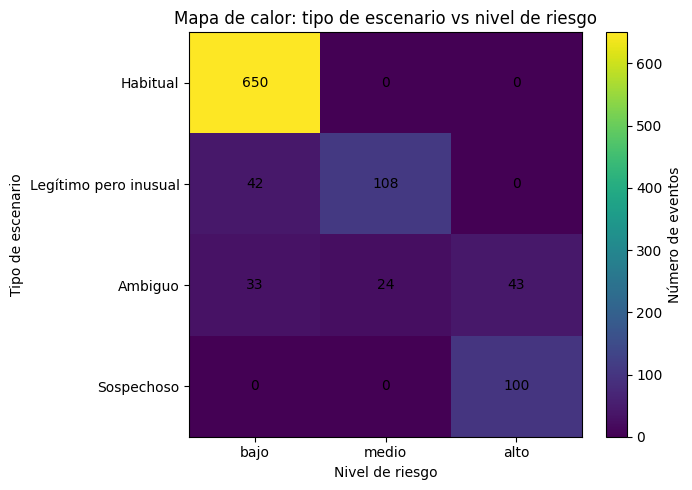

In [8]:
# 8. Mapa de calor: tipo de escenario vs nivel de riesgo

tabla_heatmap = pd.crosstab(df_results["scenario_type"], df_results["risk_level"])
tabla_heatmap = tabla_heatmap.reindex(
    index=["habitual", "legit_unusual", "ambiguous", "suspicious"],
    columns=["bajo", "medio", "alto"],
    fill_value=0
)

display(tabla_heatmap)

plt.figure(figsize=(7, 5))
plt.imshow(tabla_heatmap, aspect="auto")
plt.title("Mapa de calor: tipo de escenario vs nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Tipo de escenario")
plt.xticks(range(len(tabla_heatmap.columns)), tabla_heatmap.columns)
plt.yticks(
    range(len(tabla_heatmap.index)),
    ["Habitual", "Legítimo pero inusual", "Ambiguo", "Sospechoso"]
)

for i in range(len(tabla_heatmap.index)):
    for j in range(len(tabla_heatmap.columns)):
        plt.text(j, i, tabla_heatmap.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.show()

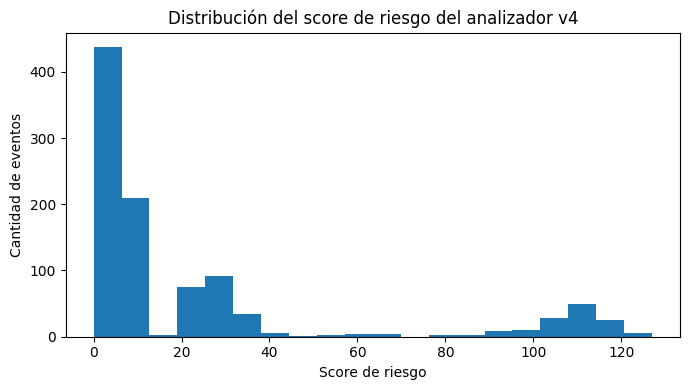

In [9]:
# 9. Histograma del score de riesgo

plt.figure(figsize=(7, 4))
df_results["risk_score"].plot(kind="hist", bins=20)
plt.title("Distribución del score de riesgo del analizador v4")
plt.xlabel("Score de riesgo")
plt.ylabel("Cantidad de eventos")
plt.tight_layout()
plt.show()

,Umbral medio,Umbral alto,Aciertos,Subestimaciones,Sobrestimaciones,Accuracy
6,25,55,937,35,28,0.937
7,25,60,937,35,28,0.937
5,25,50,934,35,31,0.934
4,25,45,933,35,32,0.933
2,20,55,932,0,68,0.932
3,20,60,932,0,68,0.932
1,20,50,929,0,71,0.929
0,20,45,928,0,72,0.928
11,30,60,873,112,15,0.873
10,30,55,873,112,15,0.873


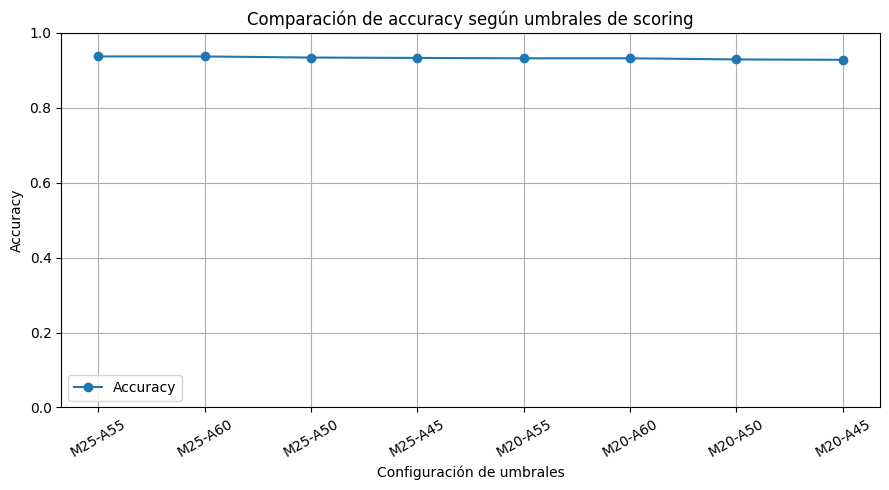

In [10]:
# 10. Análisis de umbrales de scoring

def clasificar_por_umbrales(score, umbral_medio, umbral_alto):
    if score >= umbral_alto:
        return "alto"
    elif score >= umbral_medio:
        return "medio"
    else:
        return "bajo"

resultados_umbrales = []
orden = {"bajo": 1, "medio": 2, "alto": 3}

for umbral_medio in [20, 25, 30, 35]:
    for umbral_alto in [45, 50, 55, 60]:
        if umbral_medio >= umbral_alto:
            continue

        clasificacion_temp = df_results["risk_score"].apply(
            lambda x: clasificar_por_umbrales(x, umbral_medio, umbral_alto)
        )

        comparaciones_temp = []

        for esperado, obtenido in zip(df_results["expected_result"], clasificacion_temp):
            esperado = str(esperado).lower()
            obtenido = str(obtenido).lower()

            if esperado == obtenido:
                comparaciones_temp.append("acierto")
            elif orden[obtenido] < orden[esperado]:
                comparaciones_temp.append("subestimacion")
            else:
                comparaciones_temp.append("sobrestimacion")

        comparaciones_temp = pd.Series(comparaciones_temp)

        resultados_umbrales.append({
            "Umbral medio": umbral_medio,
            "Umbral alto": umbral_alto,
            "Aciertos": int((comparaciones_temp == "acierto").sum()),
            "Subestimaciones": int((comparaciones_temp == "subestimacion").sum()),
            "Sobrestimaciones": int((comparaciones_temp == "sobrestimacion").sum()),
            "Accuracy": float((comparaciones_temp == "acierto").mean())
        })

tabla_umbrales = pd.DataFrame(resultados_umbrales)
tabla_umbrales = tabla_umbrales.sort_values(by="Accuracy", ascending=False)

display(tabla_umbrales.head(10))

top_umbrales = tabla_umbrales.head(8).copy()
top_umbrales["Configuración"] = (
    "M" + top_umbrales["Umbral medio"].astype(str) +
    "-A" + top_umbrales["Umbral alto"].astype(str)
)

plt.figure(figsize=(9, 5))
plt.plot(top_umbrales["Configuración"], top_umbrales["Accuracy"], marker="o", label="Accuracy")
plt.title("Comparación de accuracy según umbrales de scoring")
plt.xlabel("Configuración de umbrales")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

=== Métricas por clase ===


,Clase,Soporte,Precisión,Recall,F1
0,bajo,703,0.952,0.982,0.966
1,medio,172,0.902,0.692,0.783
2,alto,125,0.874,1.000,0.933


Macro-F1: 0.894
Accuracy global: 93.40%  (IC95%: 91.86% - 94.94%)
Línea base (clase mayoritaria): 70.30%

=== Ablación de localización ===
Accuracy CON localización: 93.40%
Accuracy SIN localización: 82.10%
Caída: 11.3 puntos
Recall 'alto': con loc 1.000 | sin loc 0.856


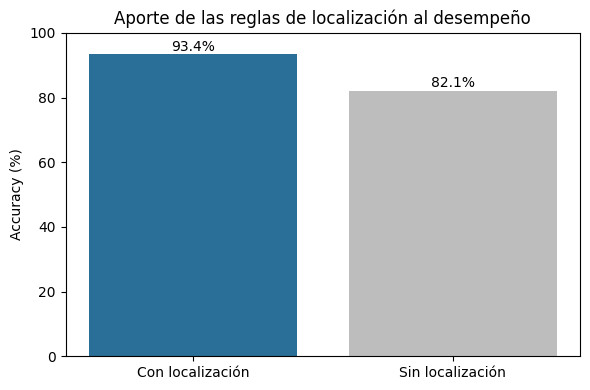

In [11]:
# 11. Métricas por clase + análisis de ablación de localización
import numpy as np
from src.risk_engine import CONFIG, classify_score

orden = ["bajo", "medio", "alto"]
yt = df_results["expected_result"].reset_index(drop=True)
yp = df_results["risk_level"].reset_index(drop=True)

# --- Métricas por clase (precisión, recall, F1) ---
filas = []
for c in orden:
    tp = ((yp == c) & (yt == c)).sum()
    fp = ((yp == c) & (yt != c)).sum()
    fn = ((yp != c) & (yt == c)).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec  = tp / (tp + fn) if (tp + fn) else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    filas.append([c, int((yt == c).sum()), round(prec, 3), round(rec, 3), round(f1, 3)])

tabla_metricas_clase = pd.DataFrame(filas, columns=["Clase", "Soporte", "Precisión", "Recall", "F1"])
macro_f1 = round(tabla_metricas_clase["F1"].mean(), 3)
linea_base = yt.value_counts(normalize=True).max()
n = len(yt); acc = (yt == yp).mean(); ic = 1.96 * np.sqrt(acc * (1 - acc) / n)

print("=== Métricas por clase ===")
display(tabla_metricas_clase)
print(f"Macro-F1: {macro_f1}")
print(f"Accuracy global: {acc:.2%}  (IC95%: {acc-ic:.2%} - {acc+ic:.2%})")
print(f"Línea base (clase mayoritaria): {linea_base:.2%}")

# --- Ablación: recalcular el score IGNORANDO las reglas de localización ---
def score_sin_localizacion(ev, cfg):
    w = cfg["weights"]; s = 0
    if int(pd.to_numeric(ev.get("is_new_device"), errors="coerce") or 0) == 1: s += w["new_device"]
    nt = str(ev.get("network_type") or "").strip().lower()
    if nt in cfg["risky_networks"]: s += w["risky_network"]
    if int(pd.to_numeric(ev.get("is_proxy"), errors="coerce") or 0) == 1: s += w["proxy_indicator"]
    if int(pd.to_numeric(ev.get("is_vpn"), errors="coerce") or 0) == 1: s += w["vpn_indicator"]
    if int(pd.to_numeric(ev.get("is_hosting"), errors="coerce") or 0) == 1: s += w["hosting_indicator"]
    if int(pd.to_numeric(ev.get("timezone_mismatch"), errors="coerce") or 0) == 1: s += w["timezone_mismatch"]
    ipr = str(ev.get("ip_reputation") or "").strip().lower()
    if ipr == "high": s += w["high_ip_reputation"]
    elif ipr == "medium": s += w["medium_ip_reputation"]
    return classify_score(s, cfg)

yp_abl = df.apply(lambda r: score_sin_localizacion(r.to_dict(), CONFIG), axis=1).reset_index(drop=True)

def recall_alto(yt, yp):
    tp = ((yp == "alto") & (yt == "alto")).sum(); fn = ((yp != "alto") & (yt == "alto")).sum()
    return tp / (tp + fn) if (tp + fn) else 0

acc_full, acc_abl = (yt == yp).mean(), (yt == yp_abl).mean()
print("\n=== Ablación de localización ===")
print(f"Accuracy CON localización: {acc_full:.2%}")
print(f"Accuracy SIN localización: {acc_abl:.2%}")
print(f"Caída: {(acc_full-acc_abl)*100:.1f} puntos")
print(f"Recall 'alto': con loc {recall_alto(yt,yp):.3f} | sin loc {recall_alto(yt,yp_abl):.3f}")

plt.figure(figsize=(6, 4))
barras = plt.bar(["Con localización", "Sin localización"], [acc_full*100, acc_abl*100],
                 color=["#2a6f97", "#bdbdbd"])
plt.ylabel("Accuracy (%)"); plt.ylim(0, 100)
plt.title("Aporte de las reglas de localización al desempeño")
for b in barras:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha="center")
plt.tight_layout()
plt.savefig("figures/ilustracion_12_ablacion_localizacion_v4.png", dpi=150, bbox_inches="tight")
plt.show()

Archivo Excel generado: outputs/resultados_analizador_localizacion_login_v4.xlsx


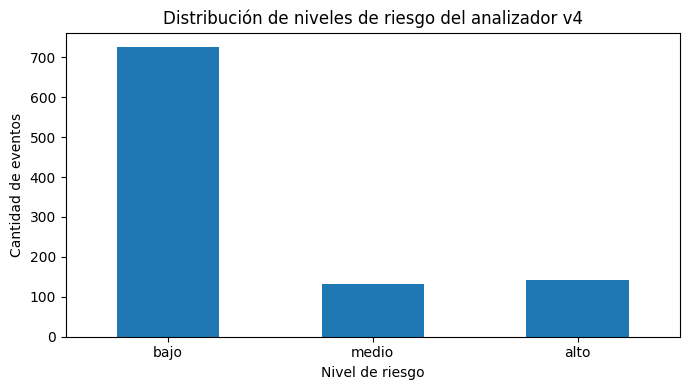

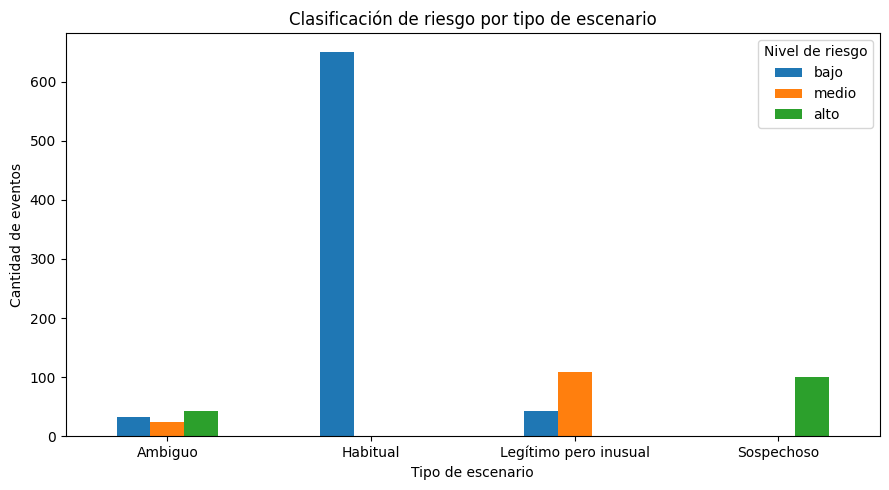

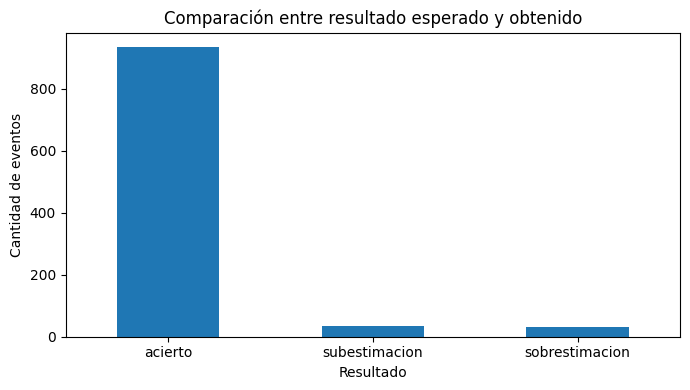

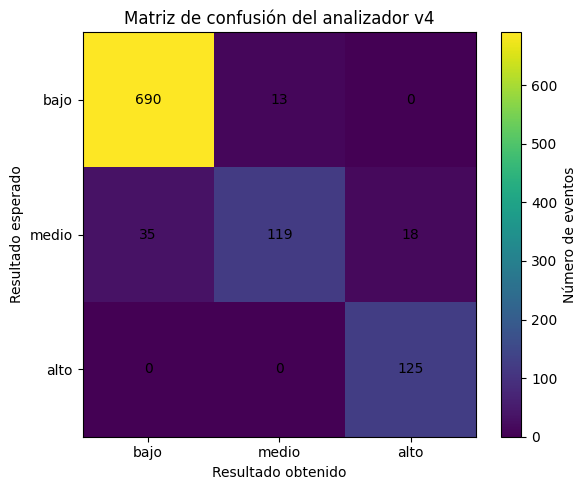

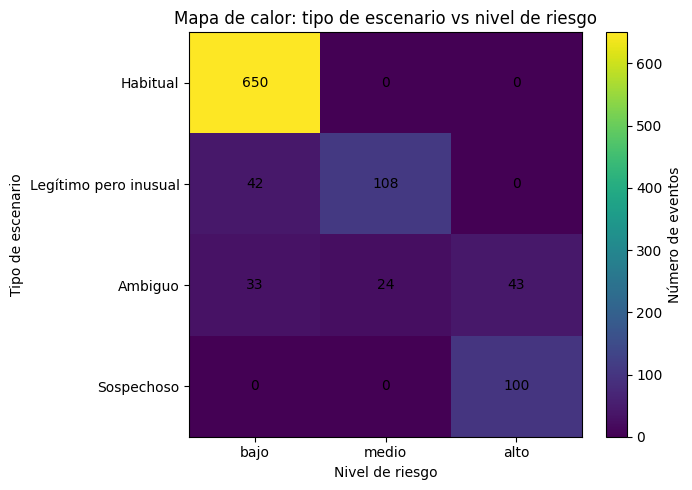

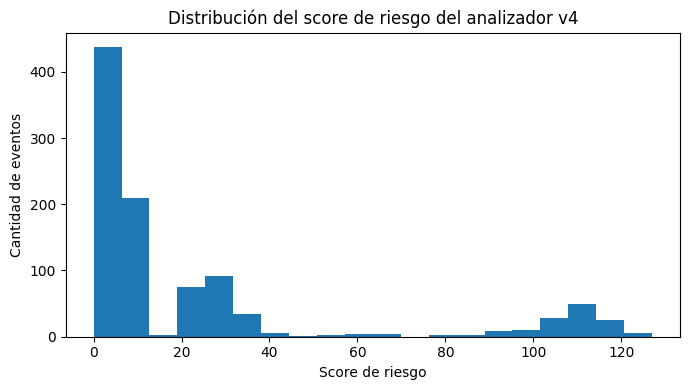

<Figure size 1000x500 with 0 Axes>

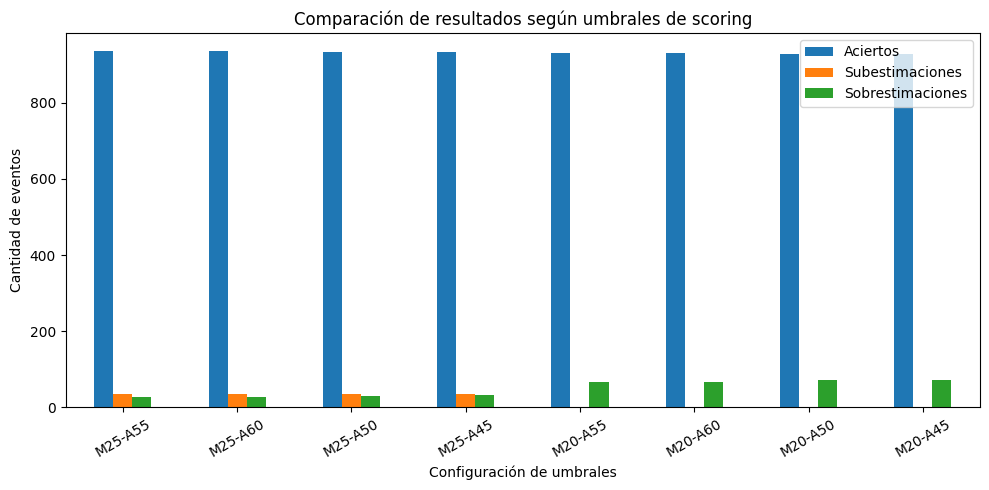

Archivo comprimido generado: resultados_tfm_analizador_localizacion_login_v4.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# 12. Exportación automática de tablas, figuras, Excel y ZIP

os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Guardar resultados en CSV
df_results.to_csv("outputs/resultados_detallados_v4.csv", index=False)
tabla_metricas.to_csv("outputs/tabla_metricas_v4.csv", index=False)
summary_risk.to_csv("outputs/tabla_riesgo_v4.csv", index=False)
summary_action.to_csv("outputs/tabla_acciones_v4.csv", index=False)
summary_comparison.to_csv("outputs/tabla_comparacion_v4.csv", index=False)
summary_by_scenario.to_csv("outputs/tabla_escenario_vs_riesgo_v4.csv", index=False)
matriz_confusion.to_csv("outputs/matriz_confusion_v4.csv")
tabla_heatmap.to_csv("outputs/tabla_heatmap_escenario_riesgo_v4.csv")
tabla_umbrales.to_csv("outputs/tabla_analisis_umbrales_v4.csv", index=False)

# Guardar tablas en Excel
excel_path = "outputs/resultados_analizador_localizacion_login_v4.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    tabla_metricas.to_excel(writer, sheet_name="metricas", index=False)
    summary_risk.to_excel(writer, sheet_name="riesgo", index=False)
    summary_action.to_excel(writer, sheet_name="acciones", index=False)
    summary_comparison.to_excel(writer, sheet_name="comparacion", index=False)
    summary_by_scenario.to_excel(writer, sheet_name="escenario_riesgo", index=False)
    matriz_confusion.to_excel(writer, sheet_name="matriz_confusion")
    tabla_heatmap.to_excel(writer, sheet_name="heatmap")
    tabla_umbrales.to_excel(writer, sheet_name="umbrales", index=False)
    df_results.to_excel(writer, sheet_name="detalle_eventos", index=False)

print("Archivo Excel generado:", excel_path)

# Figura 5: distribución de riesgo
conteo_riesgo = df_results["risk_level"].value_counts().reindex(["bajo", "medio", "alto"]).fillna(0)

plt.figure(figsize=(7, 4))
conteo_riesgo.plot(kind="bar")
plt.title("Distribución de niveles de riesgo del analizador v4")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/ilustracion_5_distribucion_riesgo_v4.png", dpi=300)
plt.show()

# Figura 6: riesgo por escenario
tabla_plot = pd.crosstab(df_results["scenario_type"], df_results["risk_level"])

tabla_plot = tabla_plot.reindex(
    index=["ambiguous", "habitual", "legit_unusual", "suspicious"],
    columns=["bajo", "medio", "alto"],
    fill_value=0
)

tabla_plot.index = ["Ambiguo", "Habitual", "Legítimo pero inusual", "Sospechoso"]

ax = tabla_plot.plot(kind="bar", figsize=(9, 5))

plt.title("Clasificación de riesgo por tipo de escenario")
plt.xlabel("Tipo de escenario")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.legend(title="Nivel de riesgo")
plt.tight_layout()
plt.savefig("figures/ilustracion_6_riesgo_por_escenario_v4.png", dpi=300)
plt.show()

# Figura 7: comparación esperado vs obtenido
comparacion_plot = (
    df_results["comparison_result"]
    .value_counts()
    .reindex(["acierto", "subestimacion", "sobrestimacion"])
    .fillna(0)
)

plt.figure(figsize=(7, 4))
comparacion_plot.plot(kind="bar")
plt.title("Comparación entre resultado esperado y obtenido")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/ilustracion_7_comparacion_esperado_obtenido_v4.png", dpi=300)
plt.show()

# Figura 8: matriz de confusión
plt.figure(figsize=(6, 5))
plt.imshow(matriz_confusion, aspect="auto")
plt.title("Matriz de confusión del analizador v4")
plt.xlabel("Resultado obtenido")
plt.ylabel("Resultado esperado")
plt.xticks(range(len(matriz_confusion.columns)), matriz_confusion.columns)
plt.yticks(range(len(matriz_confusion.index)), matriz_confusion.index)

for i in range(len(matriz_confusion.index)):
    for j in range(len(matriz_confusion.columns)):
        plt.text(j, i, matriz_confusion.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.savefig("figures/ilustracion_8_matriz_confusion_v4.png", dpi=300)
plt.show()

# Figura 9: mapa de calor
plt.figure(figsize=(7, 5))
plt.imshow(tabla_heatmap, aspect="auto")
plt.title("Mapa de calor: tipo de escenario vs nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Tipo de escenario")
plt.xticks(range(len(tabla_heatmap.columns)), tabla_heatmap.columns)
plt.yticks(
    range(len(tabla_heatmap.index)),
    ["Habitual", "Legítimo pero inusual", "Ambiguo", "Sospechoso"]
)

for i in range(len(tabla_heatmap.index)):
    for j in range(len(tabla_heatmap.columns)):
        plt.text(j, i, tabla_heatmap.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.savefig("figures/ilustracion_9_heatmap_escenario_riesgo_v4.png", dpi=300)
plt.show()

# Figura 10: histograma del score
plt.figure(figsize=(7, 4))
df_results["risk_score"].plot(kind="hist", bins=20)
plt.title("Distribución del score de riesgo del analizador v4")
plt.xlabel("Score de riesgo")
plt.ylabel("Cantidad de eventos")
plt.tight_layout()
plt.savefig("figures/ilustracion_10_histograma_score_riesgo_v4.png", dpi=300)
plt.show()

# Figura 11: comparación de umbrales
top_umbrales = tabla_umbrales.head(8).copy()

top_umbrales["Configuración"] = (
    "M" + top_umbrales["Umbral medio"].astype(str) +
    "-A" + top_umbrales["Umbral alto"].astype(str)
)

plt.figure(figsize=(10, 5))

top_umbrales.set_index("Configuración")[
    ["Aciertos", "Subestimaciones", "Sobrestimaciones"]
].plot(kind="bar", figsize=(10, 5))

plt.title("Comparación de resultados según umbrales de scoring")
plt.xlabel("Configuración de umbrales")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/ilustracion_11_comparacion_umbrales_scoring_v4.png", dpi=300)
plt.show()

# Comprimir resultados
zip_path = "resultados_tfm_analizador_localizacion_login_v4.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["outputs", "figures"]:
        for root, dirs, files in os.walk(folder):
            for file in files:
                file_path = os.path.join(root, file)
                zipf.write(file_path, arcname=file_path)

print("Archivo comprimido generado:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Descarga automática disponible solo en Google Colab.")